In [1]:
import csv
import string
from collections import Counter
import matplotlib.pyplot as plt

input_files = ["X:/Projects/ML/Assignment-1/Q3/emotion-labels-test.csv", "X:/Projects/ML/Assignment-1/Q3/emotion-labels-train.csv", "X:/Projects/ML/Assignment-1/Q3/emotion-labels-val.csv"]
output_files = ["X:/Projects/ML/Assignment-1/Q3/Dataset_1.csv", "X:/Projects/ML/Assignment-1/Q3/Dataset_2.csv", "X:/Projects/ML/Assignment-1/Q3/Dataset_3.csv"]

In [2]:
def read_csv(file_path):
    rows = []
    with open(file_path, 'r', encoding='utf-8') as file:
        csv_reader = csv.reader(file)
        for row in csv_reader:
            rows.append(','.join(row))
    return rows

def clean_csv(rows):
    cleaned_rows = []
    words = list(string.ascii_lowercase + string.ascii_uppercase)
    for i in rows:
        cleaned_data = i.replace("\n", "").replace("\t", "").replace("\b", "").replace("\f", "").replace("\r", "")
        for j in cleaned_data:
            if j not in words and j != ' ':
                cleaned_data = cleaned_data.replace(j, " ")
        cleaned_rows.append(cleaned_data)
    return cleaned_rows

def write_csv(file_path, cleaned_rows):
    with open(file_path, "w") as file:
        for cleaned_row in cleaned_rows:
            file.write(cleaned_row + "\n")
            
def filter_single(words):
    return [word for word in words if len(word) > 1 or word in {'i', 'a'}]

print("Dataset Has Been Cleaned")

Dataset Has Been Cleaned


In [3]:
final_words=[]
for i in range(3):
    all_words=[]
    lenght = 0
    
    rows = read_csv(input_files[i])
    cleaned_rows = clean_csv(rows)
    write_csv(output_files[i], cleaned_rows)
    
    all_words += [word.lower() for word in ' '.join(cleaned_rows).split()]
    all_words = filter_single(all_words)
    
    final_words += all_words
    for word in all_words:
        lenght += len(word)
        
    print(f"\nAverage Word Length Across Dataset {i+1} is {(lenght/len(all_words)):.3f}")
    
    word_counts= Counter(all_words)
    print(f"Top 10 Most Frequent Words For Dataset {i+1}:")
    for word, count in word_counts.most_common(10):
        print(f"{word}: {count}")


Average Word Length Across Dataset 1 is 4.621
Top 10 Most Frequent Words For Dataset 1:
i: 1517
the: 1344
to: 1140
fear: 1055
a: 961
and: 861
anger: 796
you: 770
joy: 733
sadness: 724

Average Word Length Across Dataset 2 is 4.635
Top 10 Most Frequent Words For Dataset 2:
the: 1741
i: 1643
to: 1289
a: 1210
fear: 1208
and: 955
anger: 912
joy: 835
sadness: 822
of: 797

Average Word Length Across Dataset 3 is 4.583
Top 10 Most Frequent Words For Dataset 3:
i: 164
the: 153
to: 138
a: 116
fear: 114
anger: 93
and: 92
of: 83
it: 83
you: 82


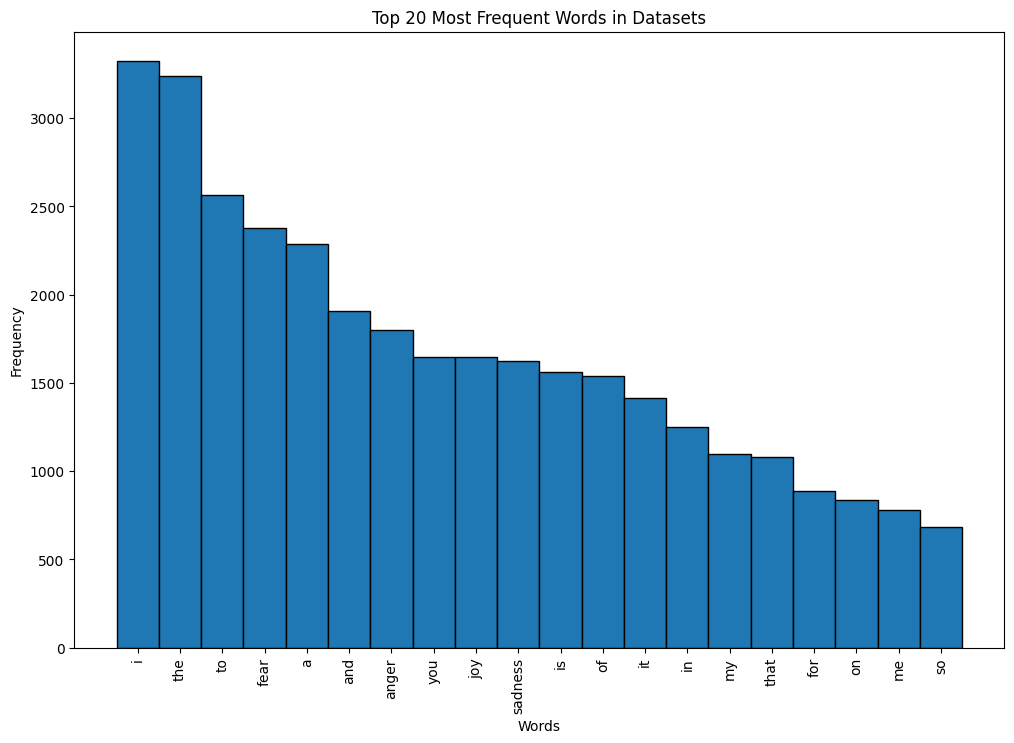

In [4]:
word_counts = Counter(final_words)
most_common = word_counts.most_common(20)
words, counts = zip(*most_common)
plt.figure(figsize=(12, 8))
plt.bar([item[0] for item in most_common], [item[1] for item in most_common], width=1.0, edgecolor='black')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.title(f'Top 20 Most Frequent Words in Datasets')
plt.show()

Some Machine Learning Methods To Solve This Problem:
1. K-Means Clustering: For grouping similar text data without prior labels.
2. Logistic Regression or Support Vector Machines: For tasks like sentiment analysis or categorizing text into specific classes.
3. Latent Dirichlet Allocation: For identifying underlying topics in your text dataset.
4. t-SNE: For visualizing clusters of high-dimensional text data.
5. Autoencoders or Isolation Forests: For detecting outliers in textual patterns.
6. Word Embedding Models: For vectorizing text into meaningful numerical formats.
7. Hierarchical Clustering: To identify natural groupings in text data.
8. Decision Trees or Random Forests: For making predictions based on text features.